# 第017讲 积分与连续量

从固定形状和支持集开始，依次核对归一化、换元、网格误差、尾部和二维区域。先修第008、013讲。先在纸上预测数值，再顺序运行全部单元。

全部函数是无量纲合成例子，不代表现实概率模型。核心脚本只使用Python标准库；绘图使用Matplotlib。有限网格核验不是一般可积性或精度证明。

In [1]:
from pathlib import Path
from fractions import Fraction
import math, sys, io
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Image
import experiment as e
base = Path(e.__file__).resolve().parent
print('Python', sys.version.split()[0], 'Matplotlib', matplotlib.__version__)
def show(fig):
    buffer = io.BytesIO()
    fig.tight_layout()
    fig.savefig(buffer, format='png', dpi=130, bbox_inches='tight')
    display(Image(data=buffer.getvalue()))
    plt.close(fig)


Python 3.12.14 Matplotlib 3.10.8


## 1 带坐标的数据和归一化
CSV中的q不是概率。先计算每个梯形的宽度与贡献，再归一化；不要把行号当坐标。

In [2]:
xs, qs = e.load_data()
for a,b,u,v in zip(xs,xs[1:],qs,qs[1:]):
    print('interval', (a,b), 'width', b-a, 'contribution', (b-a)*(u+v)/2)
Z, ps = e.normalized_samples(xs,qs)
print('Z:', Z, 'normalized integral:',e.trapezoid_samples(xs,ps))
print('p(1):',e.density(1), '[0,1] mass:',e.interval_mass(0,1))
print('[.5,1.5] mass:',e.interval_mass(.5,1.5), 'point mass:',e.interval_mass(1,1))
print('support-clipped [-1,3] mass:',e.interval_mass(-1,3))


interval (0.0, 0.25) width 0.25 contribution 0.28125
interval (0.25, 0.5) width 0.25 contribution 0.34375
interval (0.5, 0.75) width 0.25 contribution 0.40625
interval (0.75, 1.0) width 0.25 contribution 0.46875
interval (1.0, 1.25) width 0.25 contribution 0.53125
interval (1.25, 1.5) width 0.25 contribution 0.59375
interval (1.5, 1.75) width 0.25 contribution 0.65625
interval (1.75, 2.0) width 0.25 contribution 0.71875
Z: 4.0 normalized integral: 1.0
p(1): 0.5 [0,1] mass: 0.375
[.5,1.5] mass: 0.5 point mass: 0.0
support-clipped [-1,3] mass: 1.0


## 2 换元同时改变高度与宽度
Y=3X+1的支持集是[1,7]，密度须乘1/3。非线性x=u²还需要变化的因子2u。有限网格计算高次多项式只是近似。

In [3]:
print('Y total:',e.integrate(e.transformed_density,1,7,8))
print('mapped interval:',e.integrate(e.transformed_density,2.5,5.5,8))
print('missing scale:',e.integrate(lambda y:e.density((y-1)/3),1,7,8))
for n in [16,64,256,1024]:
    correct=e.integrate(lambda u:2*u**5,0,1,n)
    wrong=e.integrate(lambda u:u**4,0,1,n)
    print(n, 'correct',correct,'error vs 1/3',correct-1/3, 'missing factor',wrong,'error vs 1/5',wrong-1/5)


Y total: 1.0
mapped interval: 0.5
missing scale: 3.0
16 correct 0.33658599853515625 error vs 1/3 0.003252665201822935 missing factor 0.20130157470703125 error vs 1/5 0.001301574707031239
64 correct 0.3335367739200592 error vs 1/3 0.00020344058672588927 missing factor 0.20008137822151184 error vs 1/5 8.137822151182972e-05
256 correct 0.3333460489520803 error vs 1/3 1.2715618746994561e-05 missing factor 0.2000050862552598 error vs 1/5 5.086255259800776e-06
1024 correct 0.33333412806177876 error vs 1/3 7.947284454412618e-07 missing factor 0.20000031789140849 error vs 1/5 3.1789140847449104e-07


## 3 精确有限和与浮点误差
先用Fraction建立n=4的四个答案。随后扫描段数，保留带符号误差。

In [4]:
n=4;h=Fraction(1,n)
left=h*sum((i*h)**2 for i in range(n))
right=h*sum((i*h)**2 for i in range(1,n+1))
midpoint=h*sum(((Fraction(i)+Fraction(1,2))*h)**2 for i in range(n))
print('left',left,'right',right,'midpoint',midpoint,'trapezoid',(left+right)/2)
ns=[2,4,8,16,32,64,128,256]
errors={rule:[e.integrate(lambda x:x*x,0,1,n,rule)-1/3 for n in ns]
        for rule in ['left','right','midpoint','trapezoid']}
for rule,values in errors.items():
    print(rule,values)


left 7/32 right 15/32 midpoint 21/64 trapezoid 11/32
left [-0.20833333333333331, -0.11458333333333331, -0.059895833333333315, -0.030598958333333315, -0.015462239583333315, -0.007771809895833315, -0.003896077473958315, -0.0019505818684895648]
right [0.2916666666666667, 0.13541666666666669, 0.06510416666666669, 0.031901041666666685, 0.015787760416666685, 0.007853190104166685, 0.003916422526041685, 0.001955668131510435]
midpoint [-0.020833333333333315, -0.005208333333333315, -0.0013020833333333148, -0.00032552083333331483, -8.138020833331483e-05, -2.034505208331483e-05, -5.08626302081483e-06, -1.2715657551898296e-06]
trapezoid [0.041666666666666685, 0.010416666666666685, 0.002604166666666685, 0.0006510416666666852, 0.00016276041666668517, 4.069010416668517e-05, 1.017252604168517e-05, 2.5431315104351704e-06]


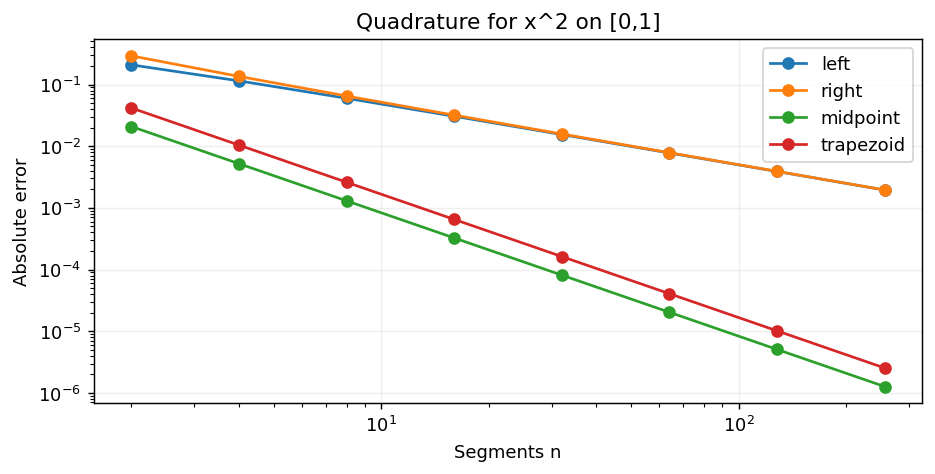

In [5]:
fig,ax=plt.subplots(figsize=(7.3,3.8))
for rule,values in errors.items():
    ax.loglog(ns,[abs(v) for v in values],'-o',label=rule)
ax.set(xlabel='Segments n',ylabel='Absolute error',title='Quadrature for x^2 on [0,1]')
ax.grid(alpha=.2);ax.legend();show(fig)


## 4 分开改变B与n
参考保留量用-expm1(-B)计算。它是稳定一些的浮点表达式，不是任意精度真值。decomposition_residual检查带符号误差分解在浮点下的残差。

In [6]:
rows=[e.exponential_audit(B,n) for B in [1,2,4,8] for n in [8,32,128,512]]
for r in rows:
    print({k:r[k] for k in ['B','n','h','discretization_signed','tail_float','total_signed','decomposition_residual']})
print('largest decomposition residual:',max(abs(r['decomposition_residual']) for r in rows))


{'B': 1.0, 'n': 8, 'h': 0.125, 'discretization_signed': 0.0008228593819223917, 'tail_float': 0.36787944117144233, 'total_signed': -0.36705658178951994, 'decomposition_residual': 0.0}
{'B': 1.0, 'n': 32, 'h': 0.03125, 'discretization_signed': 5.144126551492878e-05, 'tail_float': 0.36787944117144233, 'total_signed': -0.3678279999059274, 'decomposition_residual': 0.0}
{'B': 1.0, 'n': 128, 'h': 0.0078125, 'discretization_signed': 3.215128152489477e-06, 'tail_float': 0.36787944117144233, 'total_signed': -0.36787622604328984, 'decomposition_residual': 0.0}
{'B': 1.0, 'n': 512, 'h': 0.001953125, 'discretization_signed': 2.0094570118978083e-07, 'tail_float': 0.36787944117144233, 'total_signed': -0.36787924022574114, 'decomposition_residual': 0.0}
{'B': 2.0, 'n': 8, 'h': 0.25, 'discretization_signed': 0.004498777930079356, 'tail_float': 0.1353352832366127, 'total_signed': -0.13083650530653335, 'decomposition_residual': 0.0}
{'B': 2.0, 'n': 32, 'h': 0.0625, 'discretization_signed': 0.00028144805

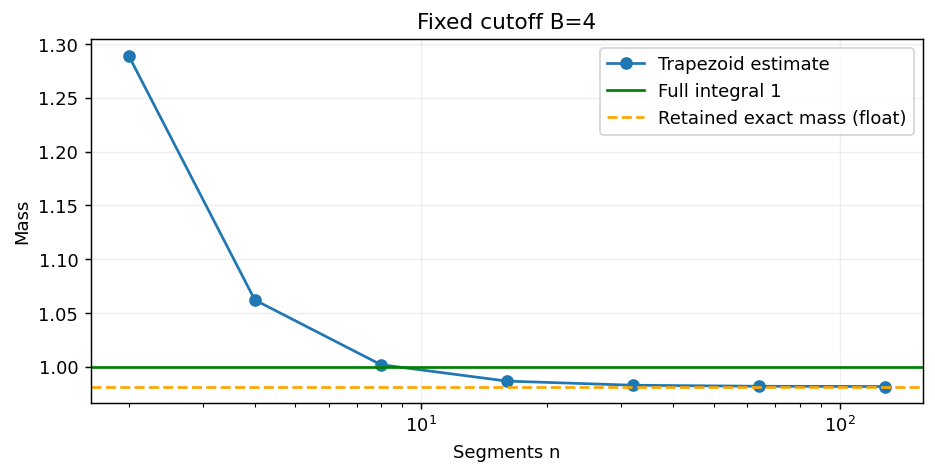

B=4 n=8: {'B': 4.0, 'n': 8, 'h': 0.5, 'estimate': 1.0020514070637834, 'exact_retained_float': 0.9816843611112658, 'tail_float': 0.01831563888873418, 'discretization_signed': 0.020367045952517593, 'total_signed': 0.0020514070637833726, 'decomposition_residual': -4.163336342344337e-17}


In [7]:
counts=[2,4,8,16,32,64,128]
fixed=[e.exponential_audit(4,n) for n in counts]
fig,ax=plt.subplots(figsize=(7.3,3.8))
ax.semilogx(counts,[r['estimate'] for r in fixed],'-o',label='Trapezoid estimate')
ax.axhline(1,c='green',label='Full integral 1')
ax.axhline(-math.expm1(-4),c='orange',ls='--',label='Retained exact mass (float)')
ax.set(xlabel='Segments n',ylabel='Mass',title='Fixed cutoff B=4')
ax.legend();ax.grid(alpha=.2);show(fig)
print('B=4 n=8:',e.exponential_audit(4,8))


## 5 二维小格与边界
相同两轴中点网格上，坐标比较等价于整数索引比较。注意每格贡献是2/n²，而不是2/n。

In [8]:
for n in [4,8,16,32,64]:
    closed=e.triangle_grid(n,True);opened=e.triangle_grid(n,False)
    print(n, 'counts',closed['selected_cells'],opened['selected_cells'],
          'masses',closed['mass'],opened['mass'], 'difference',closed['mass']-opened['mass'])
print('analytic mass:',1,'analytic event x>1/2 mass:',Fraction(3,4))


4 counts 10 6 masses 1.25 0.75 difference 0.5
8 counts 36 28 masses 1.125 0.875 difference 0.25
16 counts 136 120 masses 1.0625 0.9375 difference 0.125
32 counts 528 496 masses 1.03125 0.96875 difference 0.0625
64 counts 2080 2016 masses 1.015625 0.984375 difference 0.03125
analytic mass: 1 analytic event x>1/2 mass: 3/4


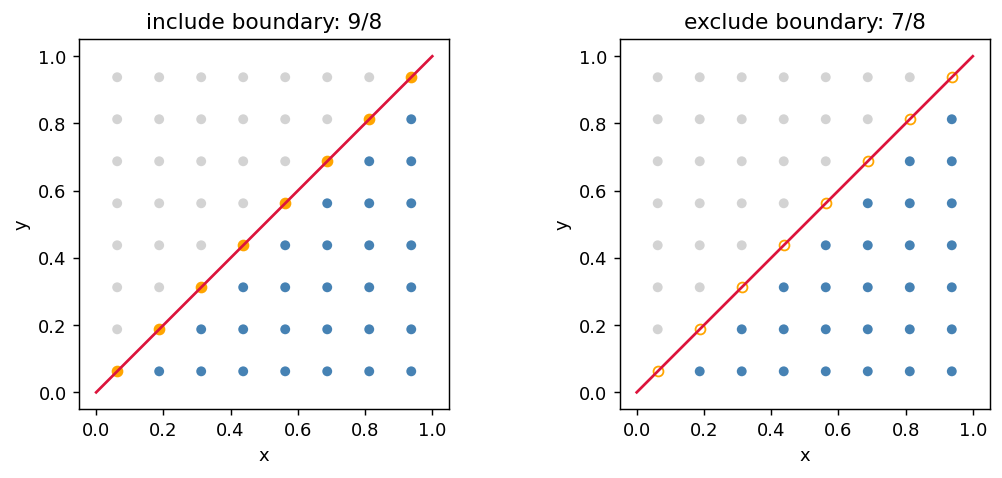

In [9]:
n=8;fig,axs=plt.subplots(1,2,figsize=(8.5,3.8))
for ax,include in zip(axs,[True,False]):
    for i in range(n):
        for j in range(n):
            selected=(j<=i if include else j<i)
            ax.scatter((i+.5)/n,(j+.5)/n,facecolors=(('orange' if include else 'white') if i==j else ('steelblue' if selected else 'lightgray')),edgecolors=('orange' if i==j else 'none'),s=30)
    ax.plot([0,1],[0,1],c='crimson');ax.set_aspect('equal')
    ax.set(xlabel='x',ylabel='y',title=('include boundary: 9/8' if include else 'exclude boundary: 7/8'))
show(fig)


## 6 两个一致的近零结果可以一起错
振荡函数真实积分为1/2，窄峰真实面积为1。对比采样节点与函数结构，不要把一致当作证明。

In [10]:
for n in [8,16,32,64,128,256,512,1024]:
    wave=e.integrate(lambda x:math.sin(16*math.pi*x)**2,0,1,n)
    peak=e.integrate(e.narrow_peak,0,1,n)
    print(n,'wave',wave,'peak',peak)
print('coarse n=16 nodes near the peak:',[x for x in e.uniform_grid(0,1,16) if .45<=x<=.62])


8 wave 1.2897934130891976e-30 peak 0.0
16 wave 4.355885488031306e-30 peak 0.0
32 wave 0.5 peak 2.7343750000000084
64 wave 0.5000000000000001 peak 1.3671875000000042
128 wave 0.5000000000000001 peak 1.025390625000002
256 wave 0.5 peak 0.988769531250001
512 wave 0.5 peak 0.99945068359375
1024 wave 0.5 peak 0.99945068359375
coarse n=16 nodes near the peak: [0.5, 0.5625]


## 7 可运行性与数学存在性分开
每个预期失败都保留清晰理由。我们不把非有限回调值或退化网格改成0。

In [11]:
cases=[('unsorted coordinates',lambda:e.trapezoid_samples([0,2,1],[1,3,2])),
       ('negative shape',lambda:e.normalized_samples([0,1],[1,-1])),
       ('collapsed grid',lambda:e.uniform_grid(1e20,math.nextafter(1e20,math.inf),4)),
       ('nonfinite return',lambda:e.integrate(lambda x:float('nan'),0,1,4))]
for name,call in cases:
    try:
        call()
    except ValueError as error:
        print(name,':',str(error))
    else:
        raise AssertionError('Expected failure did not happen')
print('small B direct:',1-math.exp(-1e-18),'expm1:',-math.expm1(-1e-18))


unsorted coordinates : sample coordinates must be strictly increasing
negative shape : density samples must be nonnegative
collapsed grid : grid has collapsed or reversed floating-point coordinates
nonfinite return : integrand return value must be finite
small B direct: 0.0 expm1: 1e-18


## 8 完整交叉核验与保存
当前497项交叉核验包含377项有理数精确等式和120项浮点实现比较。46组边界/基本结果检查不能覆盖全部浮点行为。

In [12]:
report=e.run(base/'notebook_results')
print('cross checks:',report['exact_checks'])
print('boundary/basic checks:',report['boundary_checks']['passed'])
print('result file exists:',(base/'notebook_results/report.json').is_file())


{"boundary_checks": 46, "cancellation_estimate": 1.0020514070637834, "exact_checks": 497, "interval_mass": 0.5, "normalizer": 4.0}
cross checks: {'passed': 497, 'exact_rational_checks': 377, 'floating_comparisons': 120, 'main_normalizer': '4', 'main_interval_mass': '1/2', 'polynomial_n': [1, 64], 'nonuniform_grids': 40, 'triangle_n': [1, 40]}
boundary/basic checks: 46
result file exists: True


## 解释与扩展
请用自己的话回答：主密度梯形精确的原因是什么？固定B后无限加密趋向哪个目标？重新归一化截断区间改变了什么模型？三角形的边界点为何影响有限网格？

本Notebook通过新Python进程内的真实ipykernel InProcessKernel顺序执行，保留实际输出与3张图。浏览器Jupyter界面、外进程socket和读者本机Anaconda安装未测试。依赖安装过程可能需要网络，核心实验不需要网络或付费API。